# Notebook 06: Real Population Analysis

This notebook runs the full crossing, equilibrium, and optimization pipeline on the **real imputed SRK genotype data** from *Lepidium papilliferum*.

**Prerequisites**: Run `00_load_data.ipynb` first to generate `data/imputed_population.pkl`.

**Important**: All genotypes were imputed from variable-depth sequencing data. Only 6/119 individuals had exactly 4 detected alleles. See `00_load_data.ipynb` for imputation details and confidence levels.

In [1]:
import os
import pickle
import itertools
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

# ---------------------------------------------------------------------------
# Utility functions (from Notebooks 01-04)
# ---------------------------------------------------------------------------

def canonical(alleles):
    """Return the canonical (sorted tuple) form of a genotype."""
    return tuple(sorted(alleles))

def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies (proportion of each S-allele in the population)."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))

def form_gametes(genotype):
    """Return all C(4,2)=6 diploid gametes from a tetraploid genotype."""
    return list(itertools.combinations(genotype, 2))

def is_compatible(maternal_genotype, pollen_gamete):
    """Check SI compatibility: True if pollen shares no alleles with maternal plant."""
    maternal_alleles = set(maternal_genotype)
    return not any(a in maternal_alleles for a in pollen_gamete)

def cross(parent_a, parent_b):
    """Compute offspring genotype probabilities for a directed cross (maternal x pollen)."""
    maternal_gametes = form_gametes(parent_a)
    paternal_gametes = form_gametes(parent_b)
    compatible_paternal = [g for g in paternal_gametes if is_compatible(parent_a, g)]
    if not compatible_paternal:
        return {}
    offspring_counts = Counter()
    total_combinations = len(maternal_gametes) * len(compatible_paternal)
    for mg in maternal_gametes:
        for pg in compatible_paternal:
            offspring_genotype = canonical(mg + pg)
            offspring_counts[offspring_genotype] += 1
    return {g: count / total_combinations for g, count in sorted(offspring_counts.items())}

def crossing_compatibility(parent_a, parent_b):
    """Fraction of pollen gametes that pass SI (0.0 = incompatible, 1.0 = fully compatible)."""
    paternal_gametes = form_gametes(parent_b)
    compatible = sum(1 for g in paternal_gametes if is_compatible(parent_a, g))
    return compatible / len(paternal_gametes)

def sample_offspring(parent_a, parent_b):
    """Sample a single offspring from a cross (None if incompatible)."""
    offspring_dist = cross(parent_a, parent_b)
    if not offspring_dist:
        return None
    genotypes = list(offspring_dist.keys())
    probs = list(offspring_dist.values())
    idx = np.random.choice(len(genotypes), p=probs)
    return genotypes[idx]

def simulate_generation(population, n_offspring=None, crossing_plan=None):
    """Simulate one generation using random mating or a weighted crossing plan."""
    if n_offspring is None:
        n_offspring = len(population)
    next_gen = []
    if crossing_plan is not None:
        indices = list(range(len(crossing_plan)))
        weights = np.array([w for _, _, w in crossing_plan])
        weights = weights / weights.sum()
        attempts = 0
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            idx = np.random.choice(indices, p=weights)
            mi, pi, _ = crossing_plan[idx]
            child = sample_offspring(population[mi], population[pi])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    else:
        attempts = 0
        n = len(population)
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            i, j = random.sample(range(n), 2)
            child = sample_offspring(population[i], population[j])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    return next_gen

def distance_from_equilibrium(population, allele_pool):
    """Compute variance, chi-squared, and KL divergence from uniform allele frequencies."""
    freqs = allele_frequencies(population, allele_pool)
    n = len(allele_pool)
    target = 1.0 / n
    freq_values = np.array([freqs[a] for a in sorted(allele_pool)])
    variance = float(np.var(freq_values))
    chi_squared = float(np.sum((freq_values - target) ** 2 / target))
    eps = 1e-12
    freq_safe = np.maximum(freq_values, eps)
    kl_div = float(np.sum(freq_safe * np.log(freq_safe / target)))
    return {"variance": variance, "chi_squared": chi_squared, "kl_divergence": kl_div}

# ---------------------------------------------------------------------------
# Adaptive strategy helpers (re-called per generation in simulation loop)
# ---------------------------------------------------------------------------

def enumerate_compatible_crosses(pop, allele_pool):
    """Enumerate all SI-compatible directed crosses and build allele effect matrix."""
    compatible_crosses = []
    cross_allele_effects = []
    n_pop = len(pop)
    for i in range(n_pop):
        for j in range(n_pop):
            if i == j:
                continue
            compat = crossing_compatibility(pop[i], pop[j])
            if compat > 0:
                offspring_dist = cross(pop[i], pop[j])
                expected_freqs = {a: 0.0 for a in allele_pool}
                for genotype, prob in offspring_dist.items():
                    for allele in genotype:
                        if allele in expected_freqs:
                            expected_freqs[allele] += prob / 4.0
                compatible_crosses.append((i, j, compat))
                cross_allele_effects.append(expected_freqs)
    allele_effect_matrix = np.array([
        [effects[a] for a in sorted(allele_pool)]
        for effects in cross_allele_effects
    ])
    return compatible_crosses, allele_effect_matrix


def compute_greedy_weights(pop, allele_pool, compatible_crosses, allele_effect_matrix):
    """Compute greedy crossing weights that boost underrepresented alleles."""
    target_freq = 1.0 / len(allele_pool)
    current_freqs = allele_frequencies(pop, allele_pool)
    freq_array = np.array([current_freqs[a] for a in sorted(allele_pool)])
    n_crosses = len(compatible_crosses)
    greedy_scores = np.zeros(n_crosses)
    for k in range(n_crosses):
        deficit = target_freq - freq_array
        boost = allele_effect_matrix[k] - target_freq
        greedy_scores[k] = np.sum(np.maximum(deficit, 0) * np.maximum(boost, 0))
    if greedy_scores.sum() > 0:
        return greedy_scores / greedy_scores.sum()
    return np.ones(n_crosses) / n_crosses


def compute_optimal_weights(compatible_crosses, allele_effect_matrix, allele_pool, maxiter=1000):
    """Run scipy L-BFGS-B optimization to find weights minimizing chi-squared distance.

    Uses an analytical gradient to avoid finite-difference overhead, which is
    critical for large populations (e.g. 14K crosses in the real dataset).
    """
    target_freq = 1.0 / len(allele_pool)
    n_crosses = len(compatible_crosses)
    def _fitness_and_grad(weights):
        w = np.abs(weights)
        w_sum = w.sum()
        if w_sum < 1e-12:
            return 1e6, np.zeros(n_crosses)
        w_norm = w / w_sum
        expected = w_norm @ allele_effect_matrix  # (n_alleles,)
        diff = expected - target_freq
        chi_sq = float(np.sum(diff ** 2 / target_freq))
        # Analytical gradient through the normalization
        residuals = 2 * diff / target_freq  # (n_alleles,)
        g = allele_effect_matrix @ residuals  # (n_crosses,)
        grad = (g - np.dot(w_norm, g)) / w_sum
        return chi_sq, grad
    w0 = np.ones(n_crosses) / n_crosses
    result = minimize(
        _fitness_and_grad, w0, method="L-BFGS-B",
        jac=True,
        bounds=[(0, 1)] * n_crosses,
        options={"maxiter": maxiter, "ftol": 1e-12},
    )
    optimal_weights = np.abs(result.x)
    optimal_weights = optimal_weights / optimal_weights.sum()
    return optimal_weights, result

print("All utilities loaded.")

All utilities loaded.


## 1. Load Imputed Population Data

In [2]:
DATA_DIR = os.path.join("..", "data")
pkl_path = os.path.join(DATA_DIR, "imputed_population.pkl")

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

population = data["population"]
individual_names = data["individual_names"]
allele_pool_full = data["allele_pool"]
name_to_id = data["name_to_id"]
id_to_name = data["id_to_name"]
metadata = data["metadata"]
pop_groups = data["pop_groups"]
core_allele_ids = data["core_allele_ids"]

n_pop = len(population)
n_alleles_full = len(allele_pool_full)

print(f"Population: {n_pop} individuals")
print(f"Full allele pool: {n_alleles_full} alleles")
print(f"Core allele pool (in 2+ individuals): {len(core_allele_ids)} alleles")
print(f"Unique genotypes: {len(set(population))}")

Population: 119 individuals
Full allele pool: 172 alleles
Core allele pool (in 2+ individuals): 46 alleles
Unique genotypes: 108


## 2. Per-Population Summary

Each Library group (Library001–005) represents a distinct physical population. Crosses only occur within the same population. BEA_hybrid is excluded (sole member of "Other" group — no within-group crossing partners).

In [3]:
# Build group_data dict — central data structure for per-population analysis
# Exclude "Other" group (BEA_hybrid has no within-group crossing partners)
ANALYSIS_GROUPS = sorted(g for g in set(pop_groups.values()) if g != "Other")

group_colors = {
    "Library001": "#1f77b4",
    "Library002": "#ff7f0e",
    "Library003": "#2ca02c",
    "Library004": "#d62728",
    "Library005": "#9467bd",
}

group_data = {}
for group in ANALYSIS_GROUPS:
    # Extract sub-population for this group
    indices = [i for i, name in enumerate(individual_names) if pop_groups.get(name) == group]
    names = [individual_names[i] for i in indices]
    pop = [population[i] for i in indices]

    # Allele pool = all alleles present in this group
    alleles_in_group = sorted(set(a for g in pop for a in g))
    target = 1.0 / len(alleles_in_group)
    d = distance_from_equilibrium(pop, alleles_in_group)

    group_data[group] = {
        "pop": pop,
        "individuals": names,
        "indices": indices,
        "allele_pool": alleles_in_group,
        "target_freq": target,
        "n_pop": len(pop),
    }

    print(f"{group}: {len(pop)} individuals, {len(alleles_in_group)} alleles, "
          f"target freq = 1/{len(alleles_in_group)} = {target:.4f}")
    print(f"  Chi-squared: {d['chi_squared']:.4f}, Variance: {d['variance']:.6f}")

excluded = [name for name in individual_names if pop_groups.get(name) == "Other"]
print(f"\nExcluded from analysis: {excluded} (no within-group partners)")

Library001: 21 individuals, 41 alleles, target freq = 1/41 = 0.0244
  Chi-squared: 0.2900, Variance: 0.000172
Library002: 34 individuals, 49 alleles, target freq = 1/49 = 0.0204
  Chi-squared: 0.8598, Variance: 0.000358
Library003: 18 individuals, 39 alleles, target freq = 1/39 = 0.0256
  Chi-squared: 0.2940, Variance: 0.000193
Library004: 11 individuals, 21 alleles, target freq = 1/21 = 0.0476
  Chi-squared: 0.6271, Variance: 0.001422
Library005: 34 individuals, 42 alleles, target freq = 1/42 = 0.0238
  Chi-squared: 1.4206, Variance: 0.000805

Excluded from analysis: ['BEA_hybrid'] (no within-group partners)


## 3. Per-Population Allele Pools

Each group uses **all alleles present within it** as its pool. No global allele pool or target frequency — equilibrium targets are per-population.

In [4]:
# Document per-group pool sizes
print("Per-group allele pools:")
print(f"{'Group':<12} {'Individuals':>12} {'Alleles':>8} {'Target freq':>12}")
print("-" * 48)
for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    print(f"{group:<12} {gd['n_pop']:>12} {len(gd['allele_pool']):>8} "
          f"{gd['target_freq']:>12.4f}")
print()
print("No global allele_pool or target_freq variables — all analysis is per-group.")

Per-group allele pools:
Group         Individuals  Alleles  Target freq
------------------------------------------------
Library001             21       41       0.0244
Library002             34       49       0.0204
Library003             18       39       0.0256
Library004             11       21       0.0476
Library005             34       42       0.0238

No global allele_pool or target_freq variables — all analysis is per-group.


## 4. Within-Group Compatible Crosses

Enumerate SI-compatible directed crosses **within each population group** and build per-group allele effect matrices.

In [5]:
%%time

for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    pop = gd["pop"]
    allele_pool = gd["allele_pool"]
    n = gd["n_pop"]

    cc, aem = enumerate_compatible_crosses(pop, allele_pool)
    n_total = n * (n - 1)

    # Build compatibility matrix for this group
    cm = np.zeros((n, n))
    for i, j, compat in cc:
        cm[i, j] = compat

    gd["compatible_crosses"] = cc
    gd["allele_effect_matrix"] = aem
    gd["compat_matrix"] = cm

    print(f"{group}: {len(cc)}/{n_total} compatible crosses "
          f"({100*len(cc)/n_total:.1f}%), "
          f"effect matrix {aem.shape}")

Library001: 420/420 compatible crosses (100.0%), effect matrix (420, 41)
Library002: 1102/1122 compatible crosses (98.2%), effect matrix (1102, 49)
Library003: 306/306 compatible crosses (100.0%), effect matrix (306, 39)
Library004: 108/110 compatible crosses (98.2%), effect matrix (108, 21)
Library005: 1063/1122 compatible crosses (94.7%), effect matrix (1063, 42)
CPU times: user 80.5 ms, sys: 1.59 ms, total: 82 ms
Wall time: 82.1 ms


## 5. Within-Group Compatibility Heatmaps

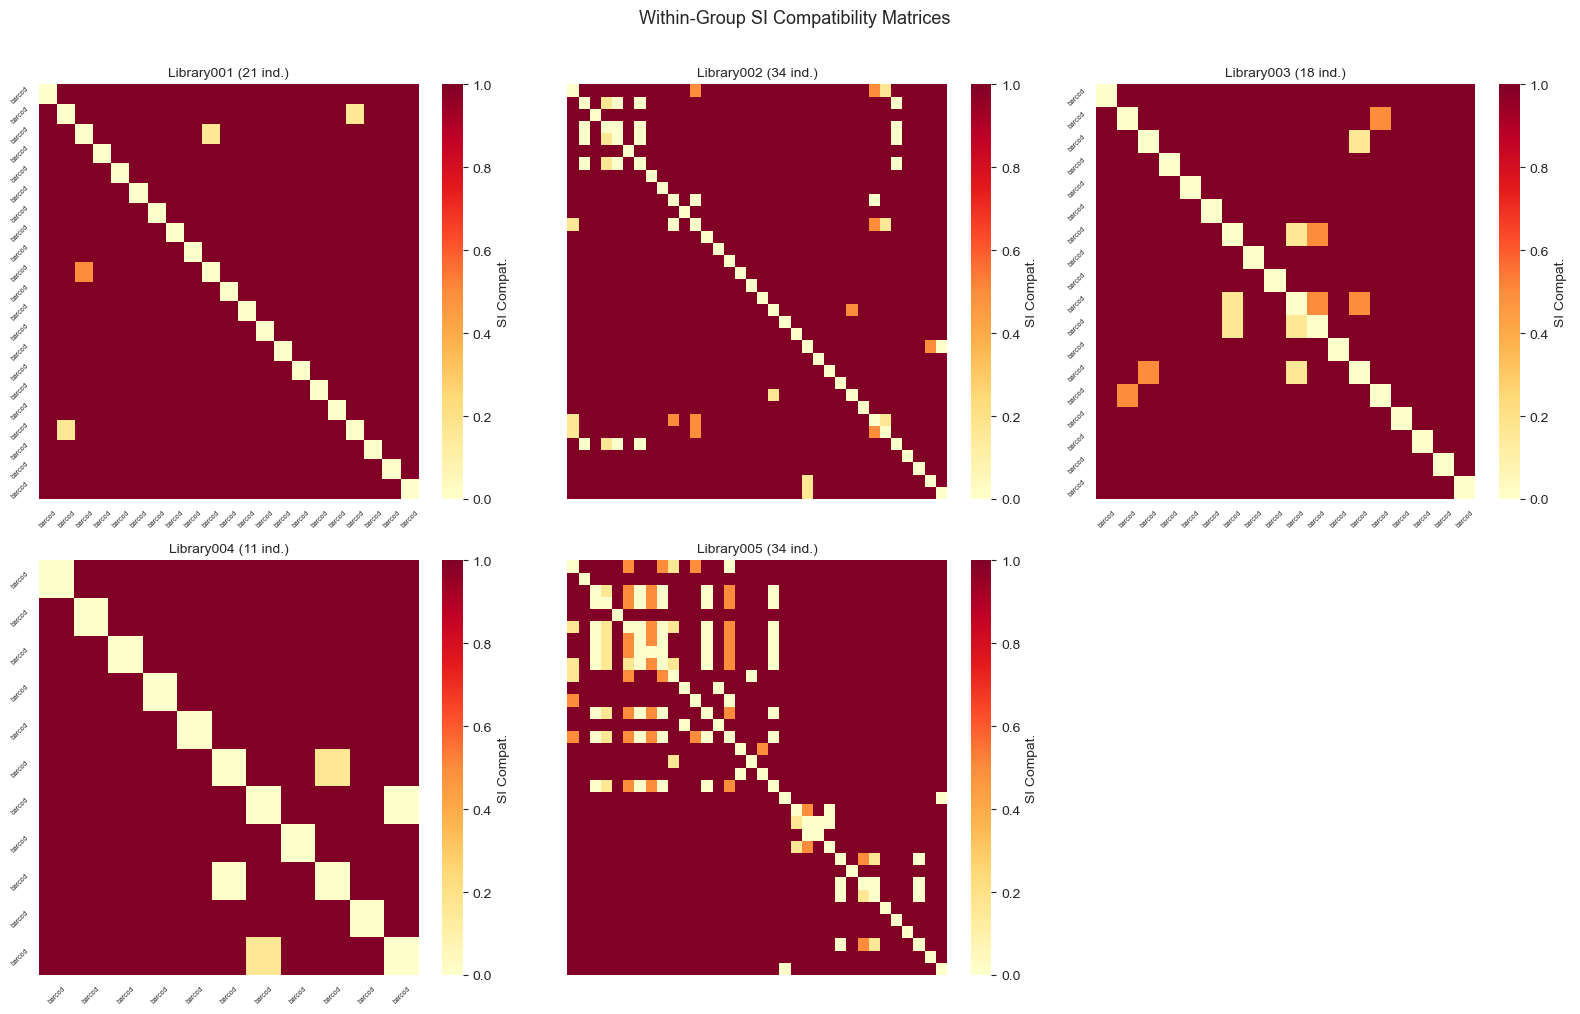

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for idx, group in enumerate(ANALYSIS_GROUPS):
    ax = axes_flat[idx]
    gd = group_data[group]
    cm = gd["compat_matrix"]
    short_names = [n.split("_")[-1][:6] for n in gd["individuals"]]

    sns.heatmap(
        cm, cmap="YlOrRd", vmin=0, vmax=1, ax=ax,
        xticklabels=short_names if gd["n_pop"] <= 30 else False,
        yticklabels=short_names if gd["n_pop"] <= 30 else False,
        cbar_kws={"label": "SI Compat."},
    )
    if gd["n_pop"] <= 30:
        ax.tick_params(axis="both", labelsize=5, labelrotation=45)
    ax.set_title(f"{group} ({gd['n_pop']} ind.)", fontsize=10)

# Hide unused subplot
axes_flat[-1].axis("off")

fig.suptitle("Within-Group SI Compatibility Matrices", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Per-Population Optimization

Find per-group weight vectors over compatible crosses that minimize chi-squared distance from NFDS equilibrium.

In [7]:
%%time

for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    cc = gd["compatible_crosses"]
    aem = gd["allele_effect_matrix"]
    allele_pool = gd["allele_pool"]
    n_crosses = len(cc)

    # Baseline chi-squared with uniform weights
    target = gd["target_freq"]
    w0 = np.ones(n_crosses) / n_crosses
    expected = w0 @ aem
    baseline_chi = float(np.sum((expected - target) ** 2 / target))

    optimal_weights, result = compute_optimal_weights(cc, aem, allele_pool, maxiter=5000)
    gd["optimal_weights"] = optimal_weights
    gd["opt_result"] = result

    print(f"{group}: {n_crosses} crosses, baseline chi²={baseline_chi:.6f}, "
          f"optimal chi²={result.fun:.6f}, "
          f"converged={result.success}, iter={result.nit}")

Library001: 420 crosses, baseline chi²=0.286810, optimal chi²=0.064014, converged=True, iter=30
Library002: 1102 crosses, baseline chi²=0.728761, optimal chi²=0.056034, converged=True, iter=79
Library003: 306 crosses, baseline chi²=0.281598, optimal chi²=0.061706, converged=True, iter=70
Library004: 108 crosses, baseline chi²=0.583462, optimal chi²=0.053512, converged=True, iter=15
Library005: 1063 crosses, baseline chi²=1.150282, optimal chi²=0.062837, converged=True, iter=194
CPU times: user 104 ms, sys: 24.2 ms, total: 128 ms
Wall time: 119 ms


## 7. Per-Population Greedy Strategy

Heuristic: score crosses by how much they boost underrepresented alleles within each group.

In [8]:
for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    gw = compute_greedy_weights(
        gd["pop"], gd["allele_pool"],
        gd["compatible_crosses"], gd["allele_effect_matrix"]
    )
    gd["greedy_weights"] = gw

    # Compute greedy chi-squared
    target = gd["target_freq"]
    expected = (gw / gw.sum()) @ gd["allele_effect_matrix"]
    greedy_chi = float(np.sum((expected - target) ** 2 / target))

    print(f"{group}: greedy chi²={greedy_chi:.6f}, "
          f"non-zero weights (>0.01): {np.sum(gw > 0.01)}")

Library001: greedy chi²=0.136157, non-zero weights (>0.01): 2
Library002: greedy chi²=0.259232, non-zero weights (>0.01): 0
Library003: greedy chi²=0.182153, non-zero weights (>0.01): 0
Library004: greedy chi²=0.146137, non-zero weights (>0.01): 45
Library005: greedy chi²=0.468968, non-zero weights (>0.01): 0


## 8. Per-Population Multi-Generation Simulation

Adaptive strategies **recompute** their crossing plan each generation. Smaller per-group populations make this much faster than the global analysis. Uses `opt_maxiter=200` per generation for tractable runtime.

In [9]:
np.random.seed(123)
random.seed(123)

n_generations = 20
n_trials = 3

def run_strategy(pop, allele_pool, n_gen, strategy="random", n_trials=3, opt_maxiter=200):
    """Run an adaptive crossing strategy for multiple generations, averaging over trials.

    Each generation re-enumerates compatible crosses and recomputes weights
    based on the current population.
    """
    all_variances = np.zeros((n_trials, n_gen + 1))
    for trial in range(n_trials):
        current_pop = list(pop)
        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen] = d["variance"]
            if gen < n_gen:
                if strategy == "random":
                    current_pop = simulate_generation(current_pop)
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)
                    if strategy == "greedy":
                        weights = compute_greedy_weights(current_pop, allele_pool, cc, aem)
                    elif strategy == "optimized":
                        weights, _ = compute_optimal_weights(cc, aem, allele_pool, maxiter=opt_maxiter)
                    else:
                        raise ValueError(f"Unknown strategy: {strategy}")
                    plan = [
                        (cc[k][0], cc[k][1], weights[k])
                        for k in range(len(cc))
                        if weights[k] > 1e-6
                    ]
                    current_pop = simulate_generation(current_pop, crossing_plan=plan)
    return all_variances.mean(axis=0), all_variances.std(axis=0)

for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    pop = gd["pop"]
    allele_pool = gd["allele_pool"]
    print(f"\n{group} ({gd['n_pop']} ind., {len(allele_pool)} alleles):")

    print("  Random mating...")
    rm, rs = run_strategy(pop, allele_pool, n_generations, "random", n_trials)
    print("  Greedy adaptive...")
    gm, gs = run_strategy(pop, allele_pool, n_generations, "greedy", n_trials)
    print("  Optimized adaptive...")
    om, os_ = run_strategy(pop, allele_pool, n_generations, "optimized", n_trials, opt_maxiter=200)

    gd["random_mean"], gd["random_std"] = rm, rs
    gd["greedy_mean"], gd["greedy_std"] = gm, gs
    gd["optimal_mean"], gd["optimal_std"] = om, os_

    print(f"  Final variance — Random: {rm[-1]:.6f}, Greedy: {gm[-1]:.6f}, Optimized: {om[-1]:.6f}")

print("\nDone.")


Library001 (21 ind., 41 alleles):
  Random mating...
  Greedy adaptive...


  Optimized adaptive...


  Final variance — Random: 0.001659, Greedy: 0.001788, Optimized: 0.000935

Library002 (34 ind., 49 alleles):
  Random mating...
  Greedy adaptive...


  Optimized adaptive...


  Final variance — Random: 0.001174, Greedy: 0.000928, Optimized: 0.000408

Library003 (18 ind., 39 alleles):
  Random mating...
  Greedy adaptive...


  Optimized adaptive...


  Final variance — Random: 0.002363, Greedy: 0.002112, Optimized: 0.001163

Library004 (11 ind., 21 alleles):
  Random mating...
  Greedy adaptive...
  Optimized adaptive...


  Final variance — Random: 0.003996, Greedy: 0.004636, Optimized: 0.002176

Library005 (34 ind., 42 alleles):
  Random mating...
  Greedy adaptive...


  Optimized adaptive...


  Final variance — Random: 0.001206, Greedy: 0.000826, Optimized: 0.000377

Done.


## 9. Per-Population Convergence

Each group's convergence shown on linear and log scales.

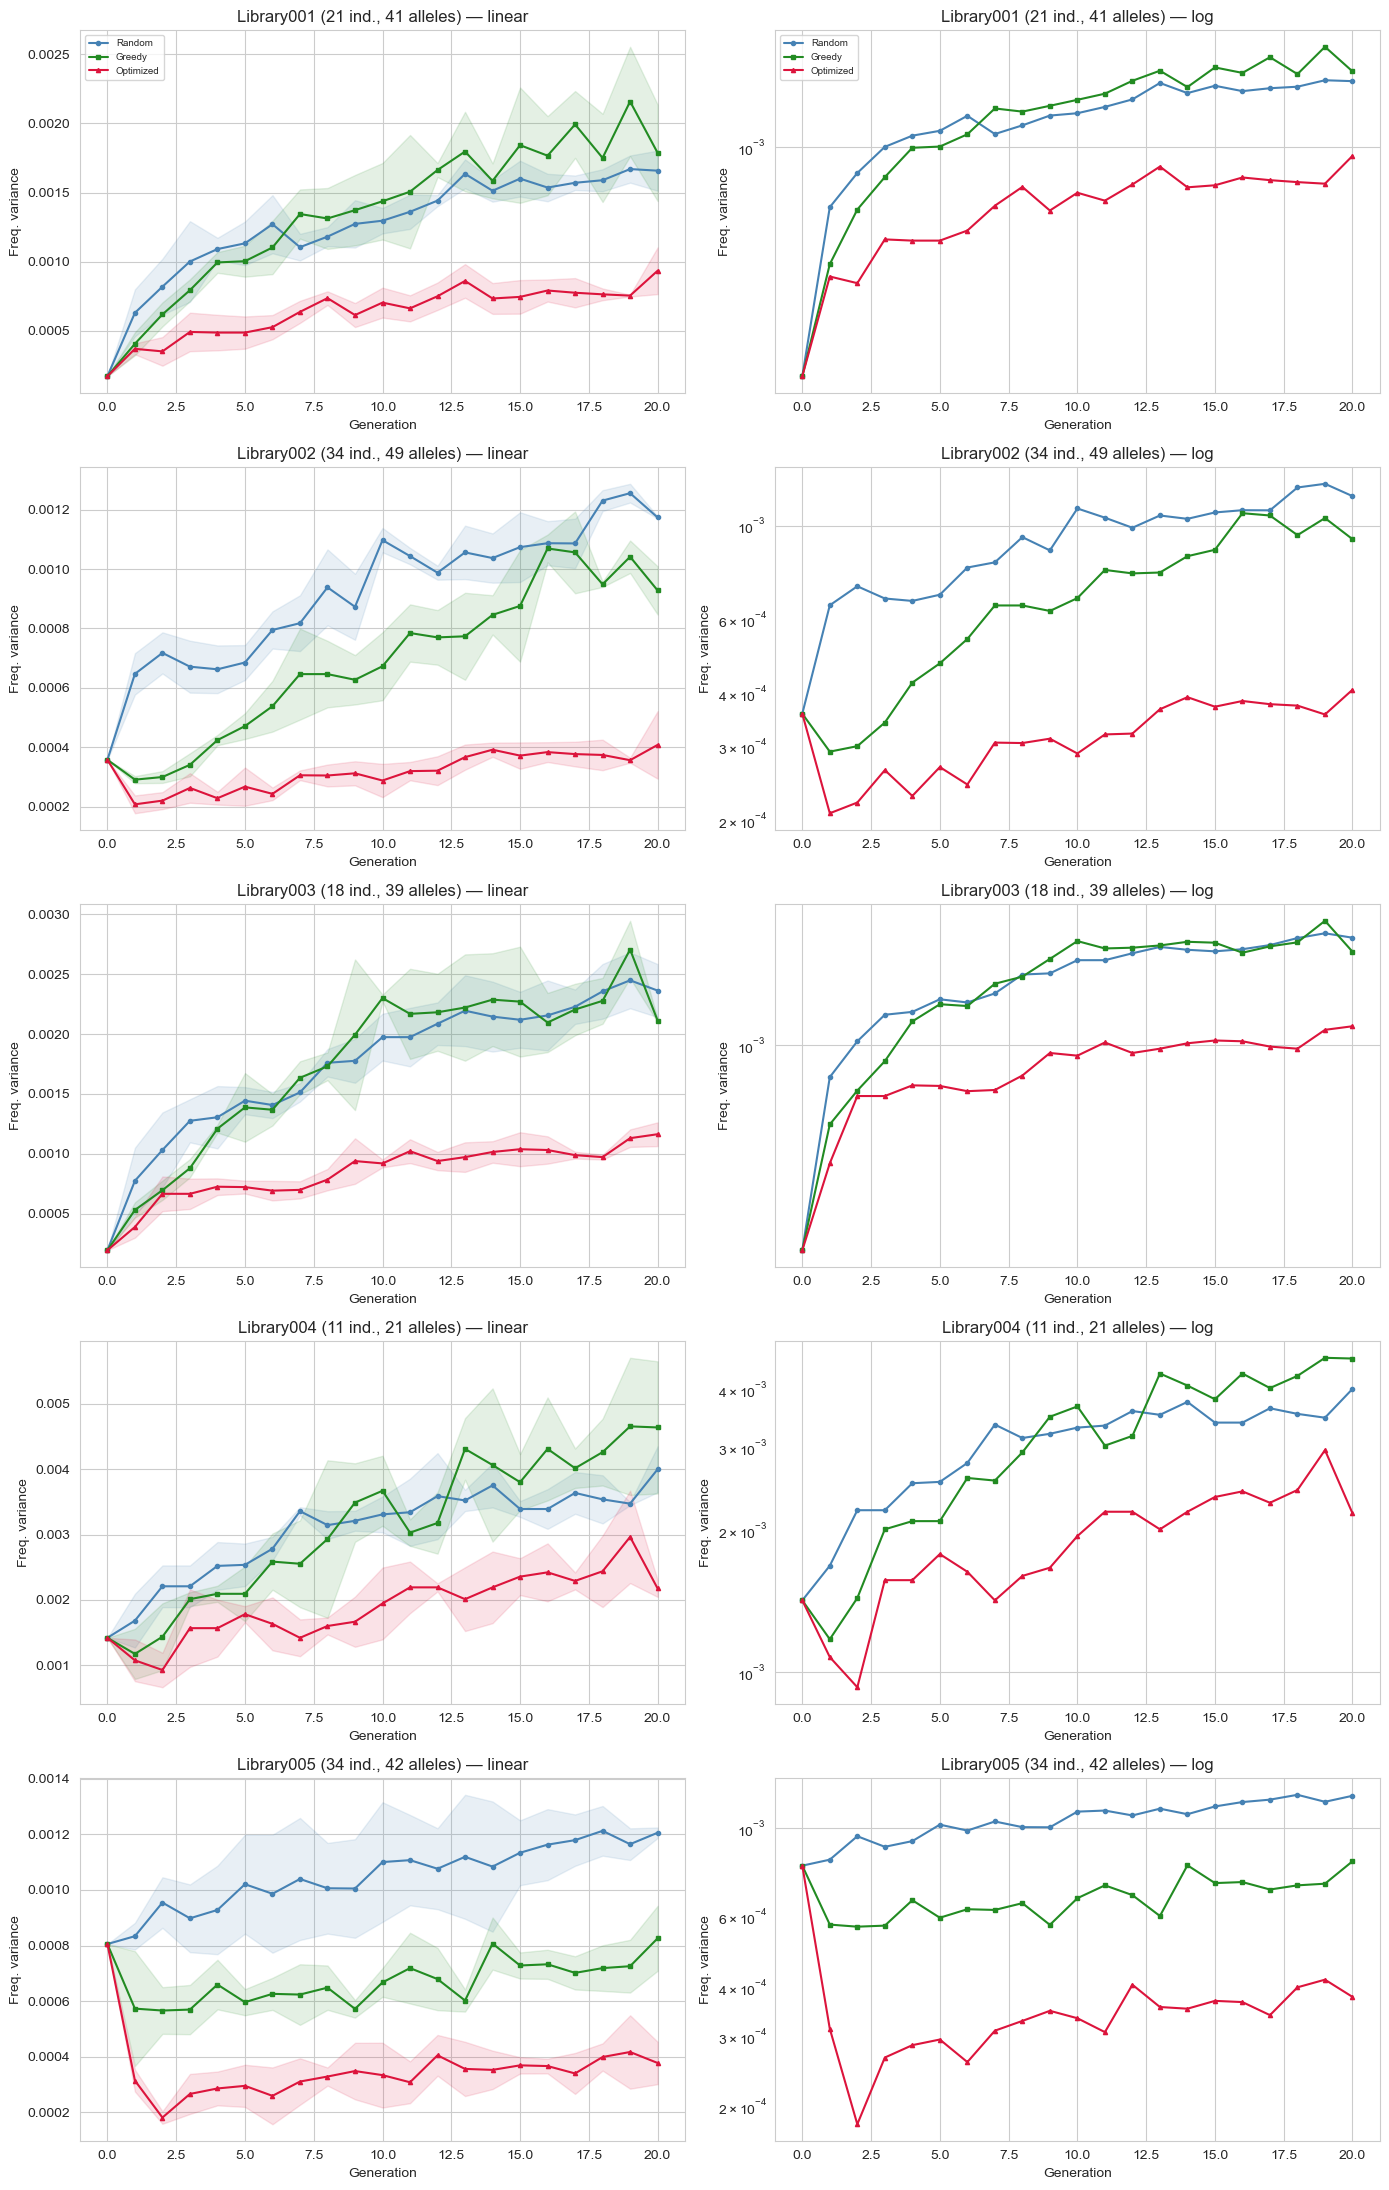

In [10]:
generations = np.arange(n_generations + 1)

fig, axes = plt.subplots(5, 2, figsize=(14, 22))

for row, group in enumerate(ANALYSIS_GROUPS):
    gd = group_data[group]
    color = group_colors[group]

    for col, (yscale, title_suffix) in enumerate([("linear", "linear"), ("log", "log")]):
        ax = axes[row, col]
        for mean, std, label, lc, marker in [
            (gd["random_mean"], gd["random_std"], "Random", "steelblue", "o"),
            (gd["greedy_mean"], gd["greedy_std"], "Greedy", "forestgreen", "s"),
            (gd["optimal_mean"], gd["optimal_std"], "Optimized", "crimson", "^"),
        ]:
            if yscale == "log":
                ax.semilogy(generations, np.maximum(mean, 1e-8),
                            f"-{marker}", color=lc, markersize=3, label=label)
            else:
                ax.plot(generations, mean, f"-{marker}", color=lc, markersize=3, label=label)
                ax.fill_between(generations, mean - std, mean + std, alpha=0.12, color=lc)

        ax.set_xlabel("Generation")
        ax.set_ylabel("Freq. variance")
        ax.set_title(f"{group} ({gd['n_pop']} ind., {len(gd['allele_pool'])} alleles) — {title_suffix}")
        if row == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 10. Top Crosses (Per Population)

In [11]:
for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    cc = gd["compatible_crosses"]
    aem = gd["allele_effect_matrix"]
    ow = gd["optimal_weights"]
    target = gd["target_freq"]
    names = gd["individuals"]

    # Current distance for this group
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])

    rows = []
    for k in range(len(cc)):
        i, j, compat = cc[k]
        expected_freqs = aem[k]
        chi_sq = float(np.sum((expected_freqs - target) ** 2 / target))
        impact = d["chi_squared"] - chi_sq
        rows.append({
            "Maternal": names[i],
            "Pollen donor": names[j],
            "Compatibility": compat,
            "Impact score": impact,
            "Optimal weight": ow[k],
        })

    df = pd.DataFrame(rows)
    df_top = df.nlargest(10, "Optimal weight").copy()
    df_top.insert(0, "Rank", range(1, len(df_top) + 1))

    print(f"\n{'='*70}")
    print(f"Top 10 Crosses — {group} ({gd['n_pop']} ind., {len(gd['allele_pool'])} alleles)")
    print(f"{'='*70}")
    print(df_top.to_string(index=False, float_format="{:.4f}".format))


Top 10 Crosses — Library001 (21 ind., 41 alleles)
 Rank             Maternal         Pollen donor  Compatibility  Impact score  Optimal weight
    1 Library001_barcode02 Library001_barcode19         0.1667      -14.0850          0.0260
    2 Library001_barcode19 Library001_barcode02         0.1667      -14.0850          0.0260
    3 Library001_barcode04 Library001_barcode11         0.1667      -12.8038          0.0246
    4 Library001_barcode11 Library001_barcode04         0.5000       -9.5295          0.0196
    5 Library001_barcode10 Library001_barcode22         1.0000       -3.8350          0.0077
    6 Library001_barcode22 Library001_barcode10         1.0000       -3.8350          0.0077
    7 Library001_barcode18 Library001_barcode22         1.0000       -6.3975          0.0076
    8 Library001_barcode22 Library001_barcode18         1.0000       -6.3975          0.0076
    9 Library001_barcode10 Library001_barcode13         1.0000       -6.3975          0.0076
   10 Library001_ba

## 11. Per-Population Crossing Networks

Top-weighted edges within each group.

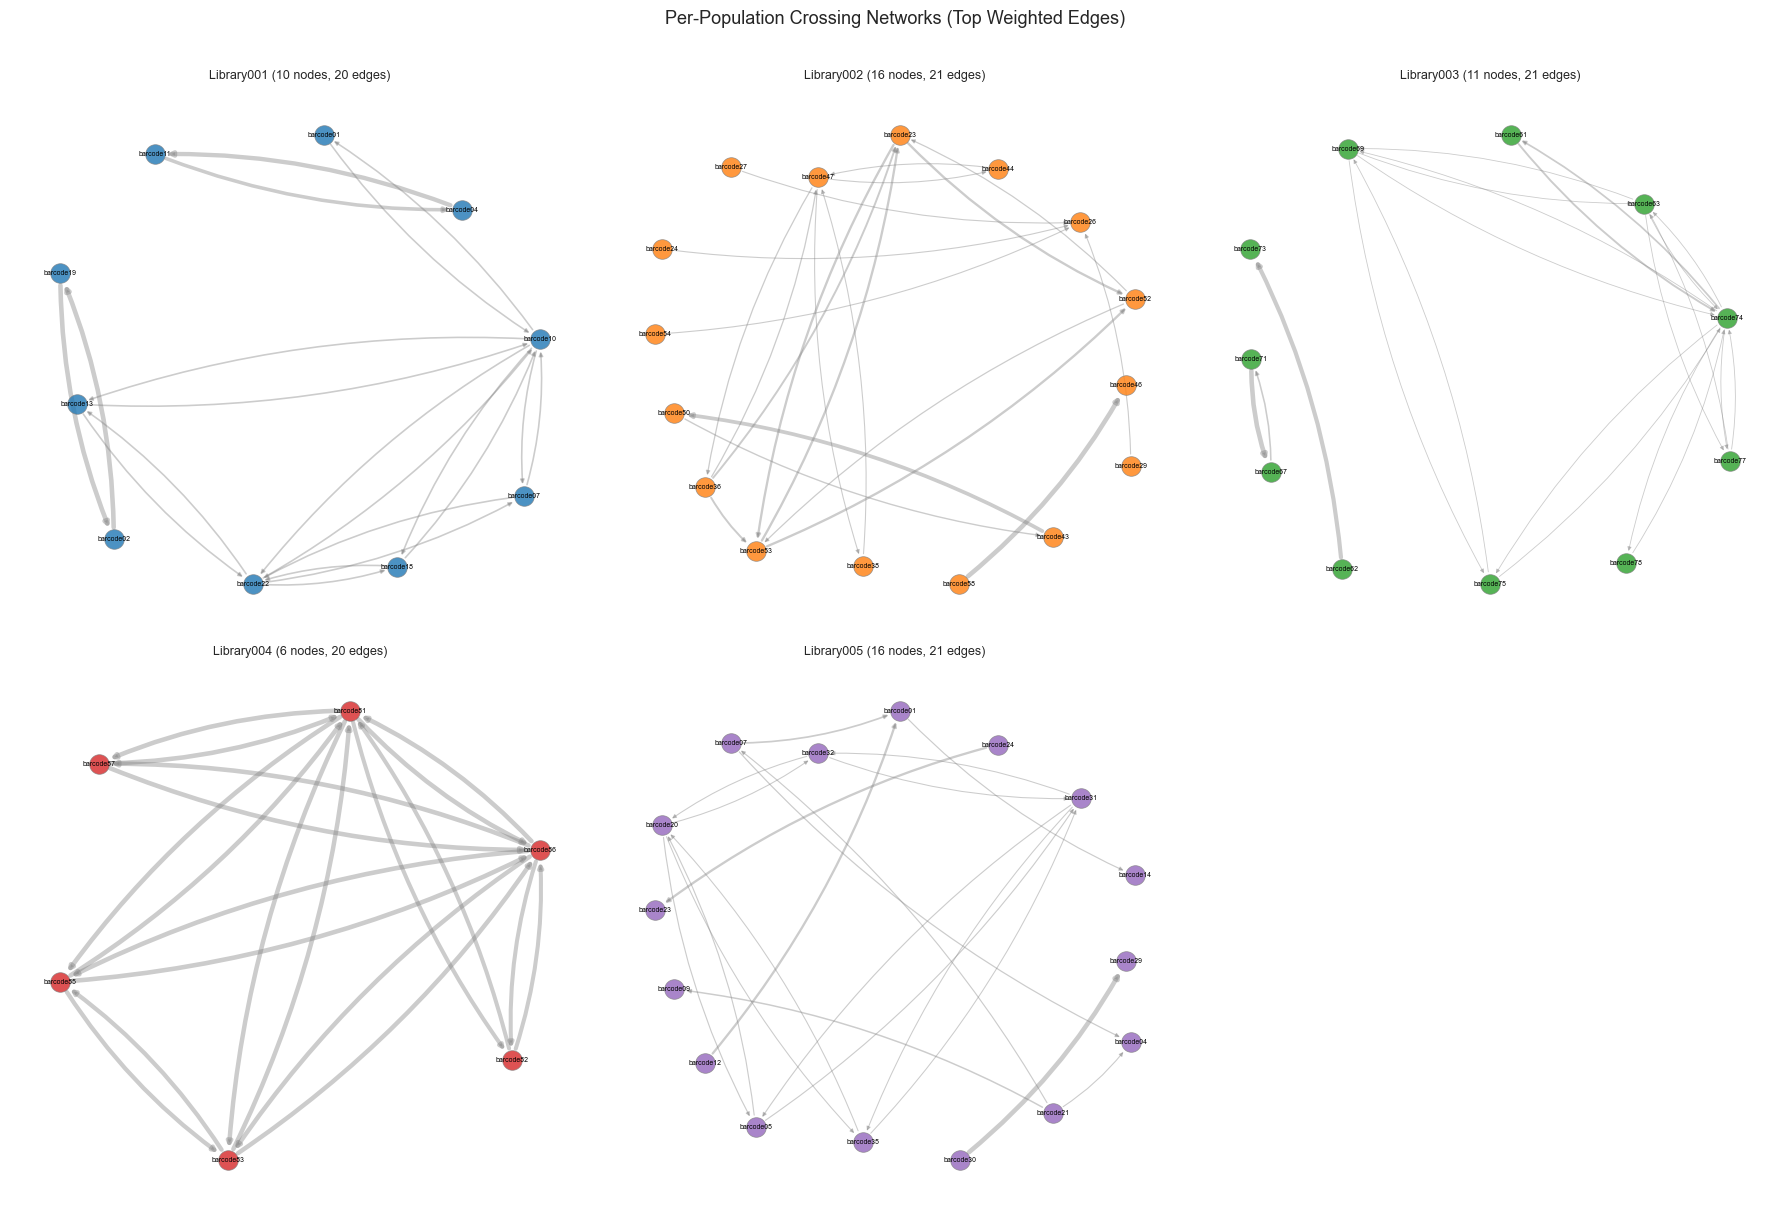

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for idx, group in enumerate(ANALYSIS_GROUPS):
    ax = axes_flat[idx]
    gd = group_data[group]
    cc = gd["compatible_crosses"]
    ow = gd["optimal_weights"]
    names = gd["individuals"]
    color = group_colors[group]

    # Threshold: top 10% of non-zero weights (or top 20 edges, whichever is fewer)
    nonzero_w = ow[ow > 1e-6]
    if len(nonzero_w) == 0:
        ax.set_title(f"{group}: no weighted crosses")
        ax.axis("off")
        continue

    threshold = np.percentile(nonzero_w, max(0, 100 - 2000 / len(nonzero_w)))

    G = nx.DiGraph()
    for k in range(len(cc)):
        if ow[k] >= threshold:
            i, j, compat = cc[k]
            ni = names[i].split("_")[-1]
            nj = names[j].split("_")[-1]
            G.add_node(i, label=ni)
            G.add_node(j, label=nj)
            G.add_edge(i, j, weight=ow[k])

    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw_networkx_nodes(G, pos, node_size=200, node_color=color,
                           edgecolors="gray", linewidths=0.5, ax=ax, alpha=0.8)
    labels = nx.get_node_attributes(G, "label")
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=5, ax=ax)

    edges = G.edges(data=True)
    if edges:
        weights = [d["weight"] for _, _, d in edges]
        max_w = max(weights) if weights else 1
        widths = [w / max_w * 3 + 0.3 for w in weights]
        nx.draw_networkx_edges(G, pos, width=widths, alpha=0.4, edge_color="gray",
                               connectionstyle="arc3,rad=0.1", arrows=True, arrowsize=6, ax=ax)

    ax.set_title(f"{group} ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)", fontsize=9)
    ax.axis("off")

axes_flat[-1].axis("off")
fig.suptitle("Per-Population Crossing Networks (Top Weighted Edges)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Per-Population Allele Frequencies

Each group's allele frequency distribution with its own NFDS target line.

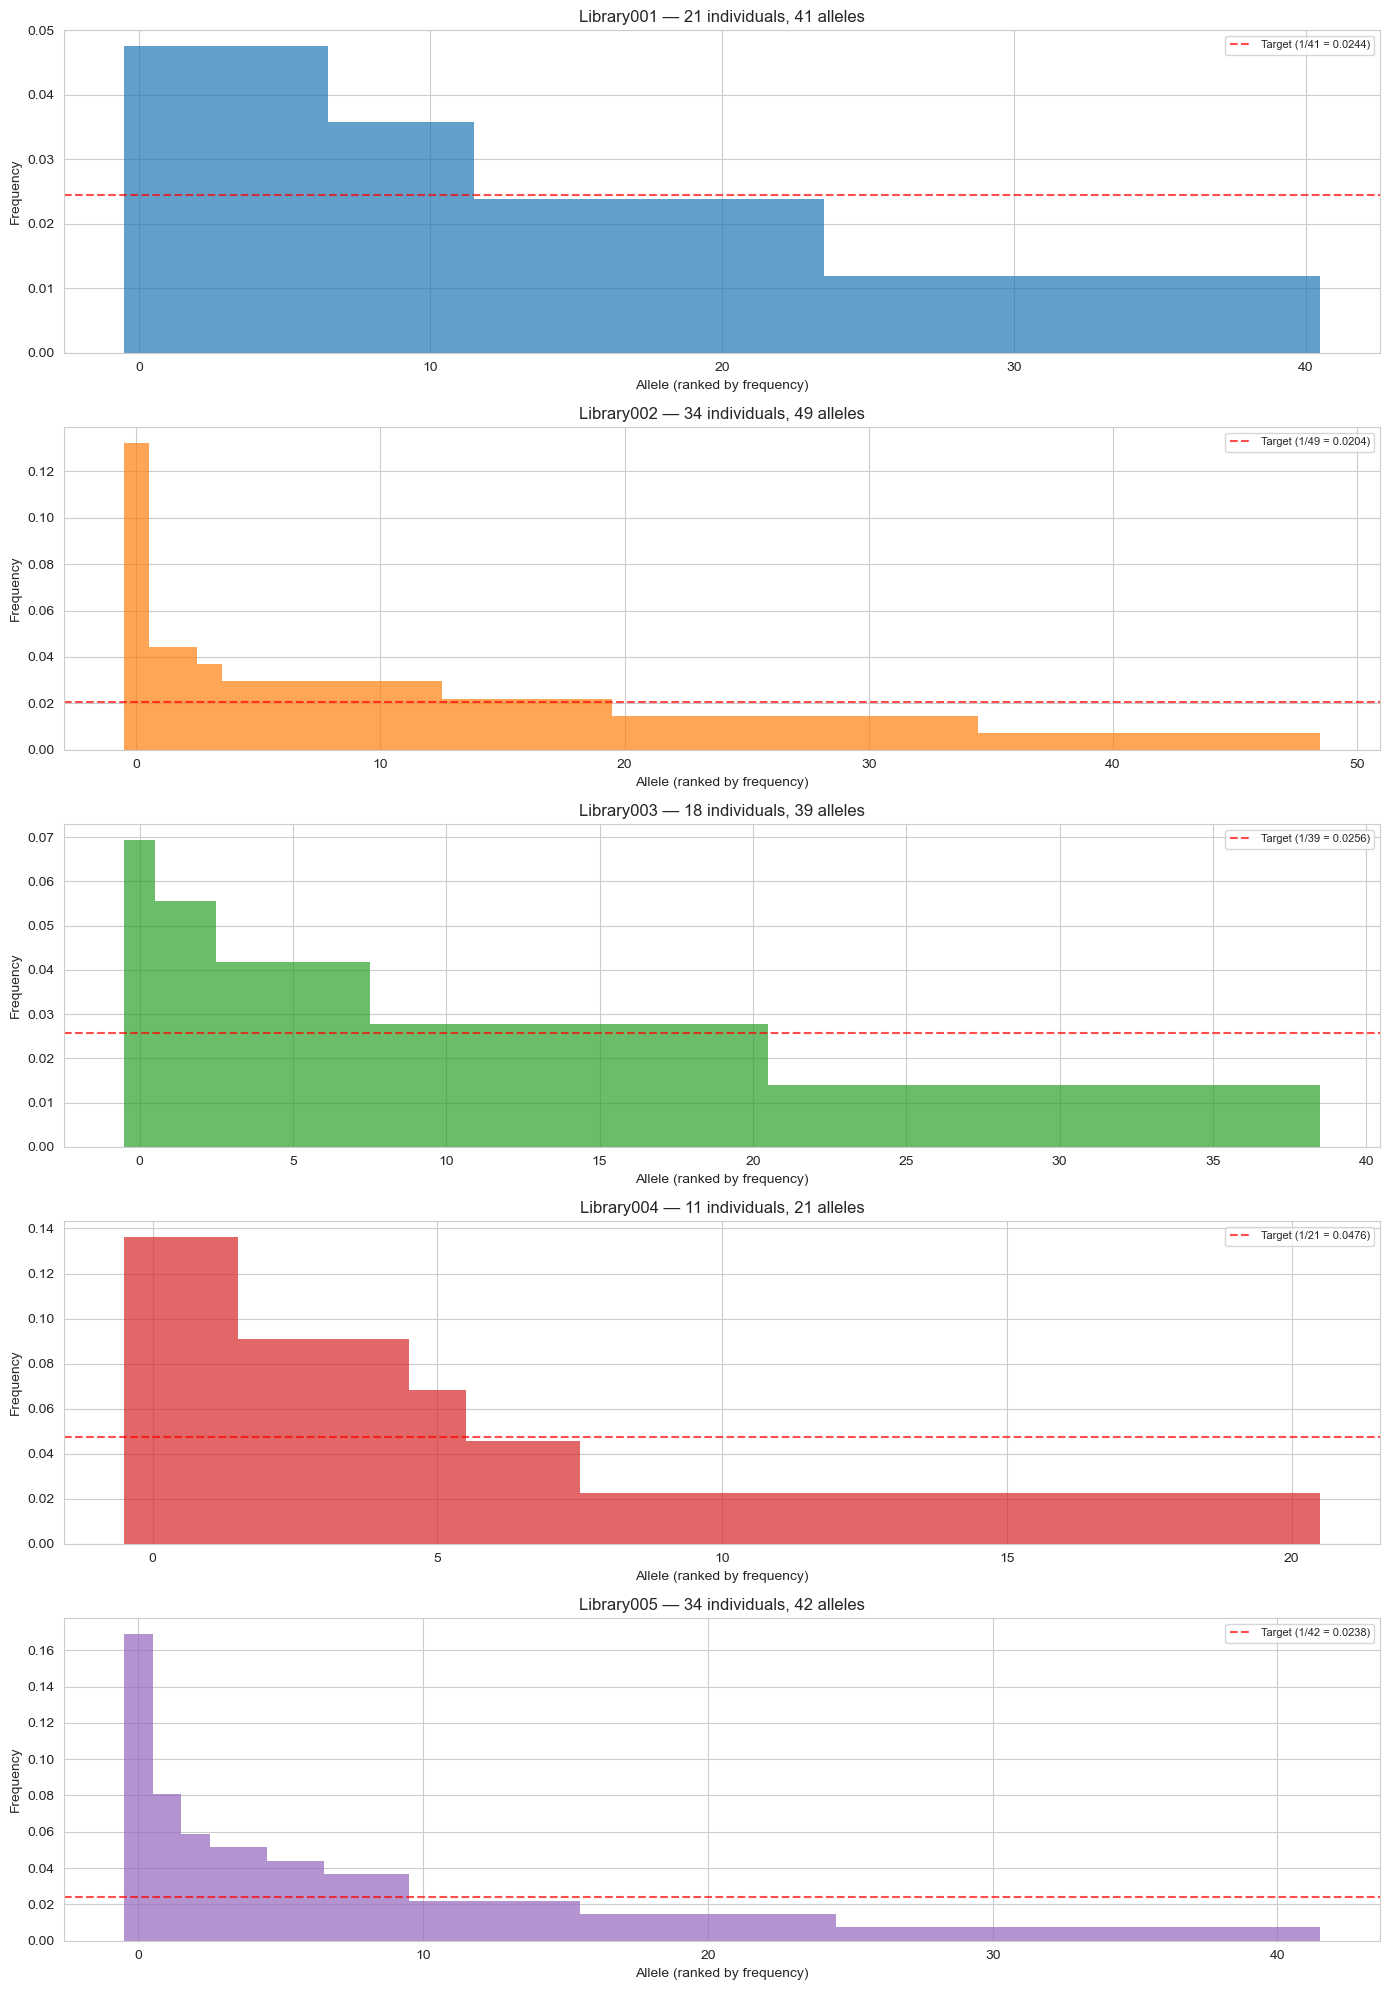

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for row, group in enumerate(ANALYSIS_GROUPS):
    ax = axes[row]
    gd = group_data[group]
    freqs = allele_frequencies(gd["pop"], gd["allele_pool"])
    sorted_alleles = sorted(gd["allele_pool"], key=lambda a: freqs.get(a, 0), reverse=True)
    freq_vals = [freqs.get(a, 0) for a in sorted_alleles]
    color = group_colors[group]

    ax.bar(range(len(freq_vals)), freq_vals, color=color, width=1.0, edgecolor="none", alpha=0.7)
    ax.axhline(y=gd["target_freq"], color="red", linestyle="--", alpha=0.7,
               label=f"Target (1/{len(gd['allele_pool'])} = {gd['target_freq']:.4f})")
    ax.set_xlabel("Allele (ranked by frequency)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{group} — {gd['n_pop']} individuals, {len(gd['allele_pool'])} alleles")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 13. Cross-Population Comparison

Summary comparison table across all 5 groups.

Cross-Population Comparison
     Group  Individuals  Alleles  Crosses  Initial chi²  Optimized chi²  Converged  Final var (Random)  Final var (Greedy)  Final var (Optimized)
Library001           21       41      420      0.289966        0.064014       True            0.001659            0.001788               0.000935
Library002           34       49     1102      0.859753        0.056034       True            0.001174            0.000928               0.000408
Library003           18       39      306      0.293981        0.061706       True            0.002363            0.002112               0.001163
Library004           11       21      108      0.627066        0.053512       True            0.003996            0.004636               0.002176
Library005           34       42     1063      1.420631        0.062837       True            0.001206            0.000826               0.000377


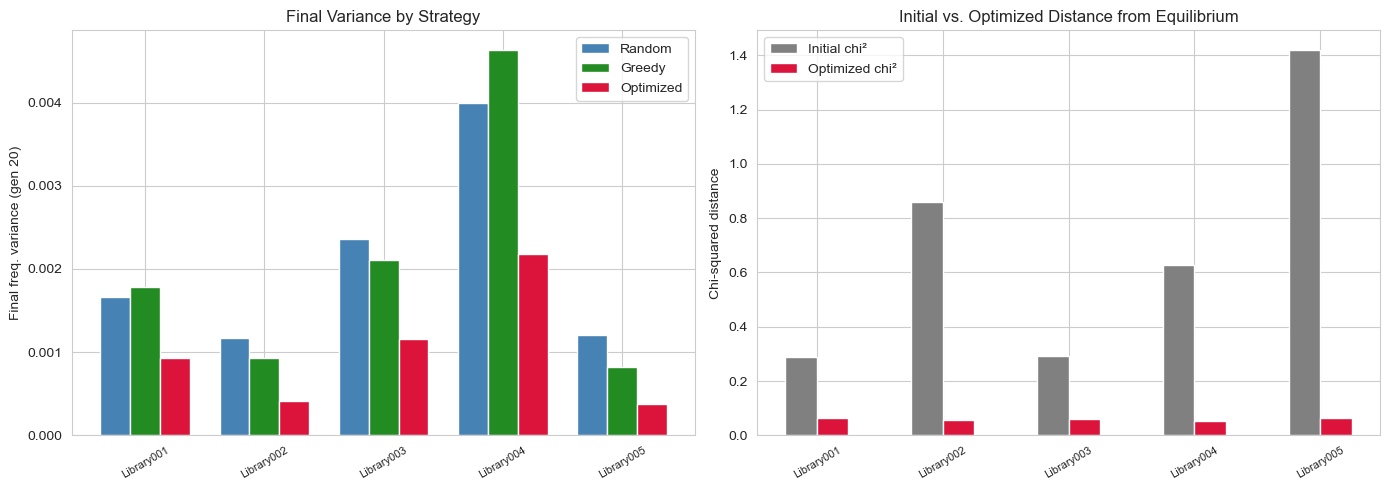

In [14]:
rows = []
for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    d = distance_from_equilibrium(gd["pop"], gd["allele_pool"])
    rows.append({
        "Group": group,
        "Individuals": gd["n_pop"],
        "Alleles": len(gd["allele_pool"]),
        "Crosses": len(gd["compatible_crosses"]),
        "Initial chi²": d["chi_squared"],
        "Optimized chi²": gd["opt_result"].fun,
        "Converged": gd["opt_result"].success,
        "Final var (Random)": gd["random_mean"][-1],
        "Final var (Greedy)": gd["greedy_mean"][-1],
        "Final var (Optimized)": gd["optimal_mean"][-1],
    })

df_summary = pd.DataFrame(rows)
print("Cross-Population Comparison")
print("=" * 100)
print(df_summary.to_string(index=False, float_format="{:.6f}".format))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(ANALYSIS_GROUPS))
width = 0.25

ax = axes[0]
ax.bar(x - width, [group_data[g]["random_mean"][-1] for g in ANALYSIS_GROUPS],
       width, label="Random", color="steelblue")
ax.bar(x, [group_data[g]["greedy_mean"][-1] for g in ANALYSIS_GROUPS],
       width, label="Greedy", color="forestgreen")
ax.bar(x + width, [group_data[g]["optimal_mean"][-1] for g in ANALYSIS_GROUPS],
       width, label="Optimized", color="crimson")
ax.set_xticks(x)
ax.set_xticklabels(ANALYSIS_GROUPS, rotation=30, fontsize=8)
ax.set_ylabel("Final freq. variance (gen 20)")
ax.set_title("Final Variance by Strategy")
ax.legend()

ax2 = axes[1]
initial = [distance_from_equilibrium(group_data[g]["pop"], group_data[g]["allele_pool"])["chi_squared"]
           for g in ANALYSIS_GROUPS]
optimized = [group_data[g]["opt_result"].fun for g in ANALYSIS_GROUPS]
ax2.bar(x - width/2, initial, width, label="Initial chi²", color="gray")
ax2.bar(x + width/2, optimized, width, label="Optimized chi²", color="crimson")
ax2.set_xticks(x)
ax2.set_xticklabels(ANALYSIS_GROUPS, rotation=30, fontsize=8)
ax2.set_ylabel("Chi-squared distance")
ax2.set_title("Initial vs. Optimized Distance from Equilibrium")
ax2.legend()

plt.tight_layout()
plt.show()

## 14. Spot-Check Validation

Verify key invariants on the real data pipeline.

In [15]:
all_ok = True

for group in ANALYSIS_GROUPS:
    gd = group_data[group]
    pop = gd["pop"]
    allele_pool = gd["allele_pool"]
    cc = gd["compatible_crosses"]
    print(f"\n--- {group} ---")

    # 1. Frequency sums to 1.0
    freq_sum = sum(allele_frequencies(pop, allele_pool).values())
    ok = abs(freq_sum - 1.0) < 1e-10
    print(f"  Freq sum = {freq_sum:.10f} {'(OK)' if ok else '(FAIL)'}")
    all_ok &= ok

    # 2. Self-incompatibility
    self_ok = all(crossing_compatibility(pop[i], pop[i]) == 0.0 for i in range(len(pop)))
    print(f"  Self-crosses = 0.0: {'(OK)' if self_ok else '(FAIL)'}")
    all_ok &= self_ok

    # 3. Optimizer convergence
    converged = gd["opt_result"].success
    print(f"  Optimizer converged: {converged} {'(OK)' if converged else '(WARN)'}")

    # 4. Offspring spot-check (first 10 crosses)
    n_checked = 0
    offspring_ok = True
    for k in range(min(10, len(cc))):
        i, j, _ = cc[k]
        offspring_dist = cross(pop[i], pop[j])
        parent_alleles = set(pop[i]) | set(pop[j])
        for g in offspring_dist:
            if len(g) != 4 or not all(a in parent_alleles for a in g):
                offspring_ok = False
            n_checked += 1
    print(f"  Offspring spot-check ({n_checked} genotypes): {'(OK)' if offspring_ok else '(FAIL)'}")
    all_ok &= offspring_ok

print(f"\n{'='*40}")
if all_ok:
    print("All per-group validation checks passed.")
else:
    print("WARNING: Some checks failed — see above.")


--- Library001 ---
  Freq sum = 1.0000000000 (OK)
  Self-crosses = 0.0: (OK)
  Optimizer converged: True (OK)
  Offspring spot-check (108 genotypes): (OK)

--- Library002 ---
  Freq sum = 1.0000000000 (OK)
  Self-crosses = 0.0: (OK)
  Optimizer converged: True (OK)
  Offspring spot-check (54 genotypes): (OK)

--- Library003 ---
  Freq sum = 1.0000000000 (OK)
  Self-crosses = 0.0: (OK)
  Optimizer converged: True (OK)
  Offspring spot-check (87 genotypes): (OK)

--- Library004 ---
  Freq sum = 1.0000000000 (OK)
  Self-crosses = 0.0: (OK)
  Optimizer converged: True (OK)
  Offspring spot-check (29 genotypes): (OK)

--- Library005 ---
  Freq sum = 1.0000000000 (OK)
  Self-crosses = 0.0: (OK)
  Optimizer converged: True (OK)
  Offspring spot-check (72 genotypes): (OK)

All per-group validation checks passed.
